In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

df = pd.read_csv("clean_used_cars.csv")
display(df.head())

,Selling Price,Brand,Model,Trim / Edition,Year of Manufacture,Transmission,Body type,Fuel type,Engine capacity,Mileage
0,4900000.0,Dfsk,Glory,330,2018,Manual,Mpv,Petrol,1500.0,90000.0
1,29500000.0,Land Rover,Range Rover Velar,R Dynamic,2018,Automatic,Suv / 4X4,Diesel,1990.0,127000.0
2,47000000.0,Mercedes Benz,S500,S500 Plus Hybrid,2015,Tiptronic,Saloon,Petrol,2996.0,112000.0
3,4000000.0,Suzuki,A-Star,Unknown,2012,Manual,Hatchback,Petrol,1000.0,120000.0
4,9450000.0,Honda,Grace,Ex,2017,Automatic,Unknown,Hybrid,1500.0,142098.0


In [5]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('Selling Price', axis=1)
y = df_encoded['Selling Price']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)

print(f"Data split complete: Train({len(X_train)}), Validation({len(X_val)}), Test({len(X_test)})")
print(f"Total features after encoding: {X_train.shape[1]}")

Data split complete: Train(1733), Validation(372), Test(372)
Total features after encoding: 1383


In [6]:
#Model Setup & Hyperparameter Tuning
xgb = XGBRegressor(random_state=42, objective='reg:squarederror')

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

print("Starting Hyperparameter Tuning")

search = RandomizedSearchCV(xgb, param_distributions=param_grid, n_iter=10,
                            scoring='neg_root_mean_squared_error', cv=3, random_state=42)

search.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

best_xgb = search.best_estimator_
print(f"\nTraining Complete!")
print(f"Best Parameters Found: {search.best_params_}")

Starting Hyperparameter Tuning

Training Complete!
Best Parameters Found: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}


In [7]:
y_pred_test = best_xgb.predict(X_test)

print("--- TEST SET EVALUATION METRICS ---")
print(f"MAE (Mean Absolute Error): Rs. {mean_absolute_error(y_test, y_pred_test):,.2f}")
print(f"RMSE (Root Mean Squared Error): Rs. {np.sqrt(mean_squared_error(y_test, y_pred_test)):,.2f}")
print(f"R-squared (R2): {r2_score(y_test, y_pred_test):.4f}")

--- TEST SET EVALUATION METRICS ---
MAE (Mean Absolute Error): Rs. 1,865,294.19
RMSE (Root Mean Squared Error): Rs. 4,994,816.99
R-squared (R2): 0.8367


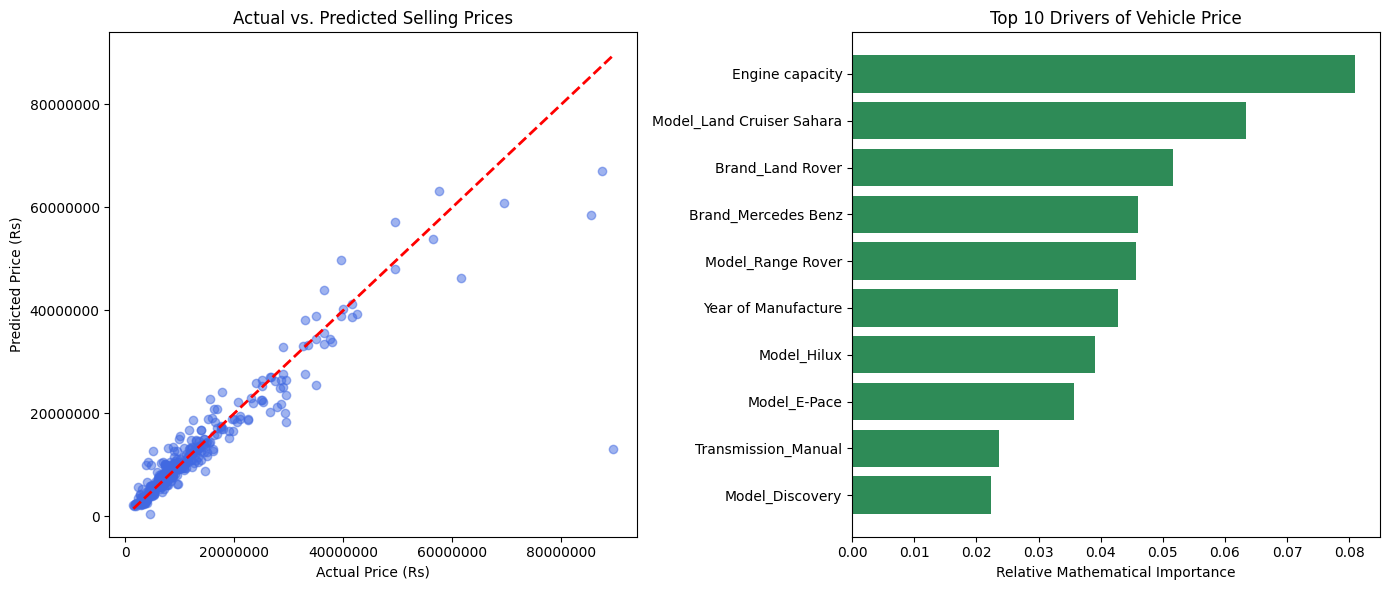

In [8]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_test, alpha=0.5, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price (Rs)")
plt.ylabel("Predicted Price (Rs)")
plt.title("Actual vs. Predicted Selling Prices")
plt.ticklabel_format(style='plain', axis='both')

plt.subplot(1, 2, 2)
importances = best_xgb.feature_importances_
indices = np.argsort(importances)[-10:]

plt.barh(range(len(indices)), importances[indices], color='seagreen', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel("Relative Mathematical Importance")
plt.title("Top 10 Drivers of Vehicle Price")

plt.tight_layout()
plt.show()

In [ ]:
!pip install shap

import shap
from sklearn.inspection import PartialDependenceDisplay

shap.initjs()

<Figure size 1200x500 with 0 Axes>

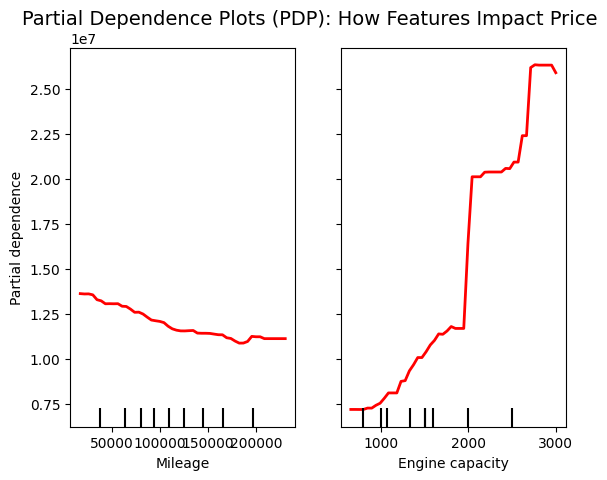


Calculating SHAP values


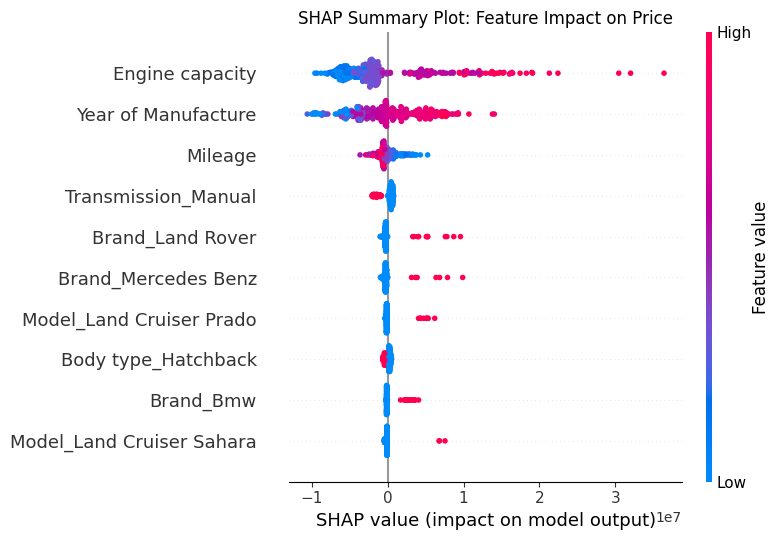

In [11]:
plt.figure(figsize=(12, 5))
features_to_plot = ['Mileage', 'Engine capacity']

disp = PartialDependenceDisplay.from_estimator(
    best_xgb, X_train, features_to_plot,
    grid_resolution=50,
    line_kw={"color": "red", "linewidth": 2}
)
plt.suptitle("Partial Dependence Plots (PDP): How Features Impact Price", fontsize=14)
plt.subplots_adjust(top=0.9)
plt.show()

print("\nCalculating SHAP values")
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot: Feature Impact on Price")
shap.summary_plot(shap_values, X_test, max_display=10)

--- Explaining Prediction for Car #0 ---
Actual Price: Rs. 3,975,000.00
Predicted Price: Rs. 2,635,363.50



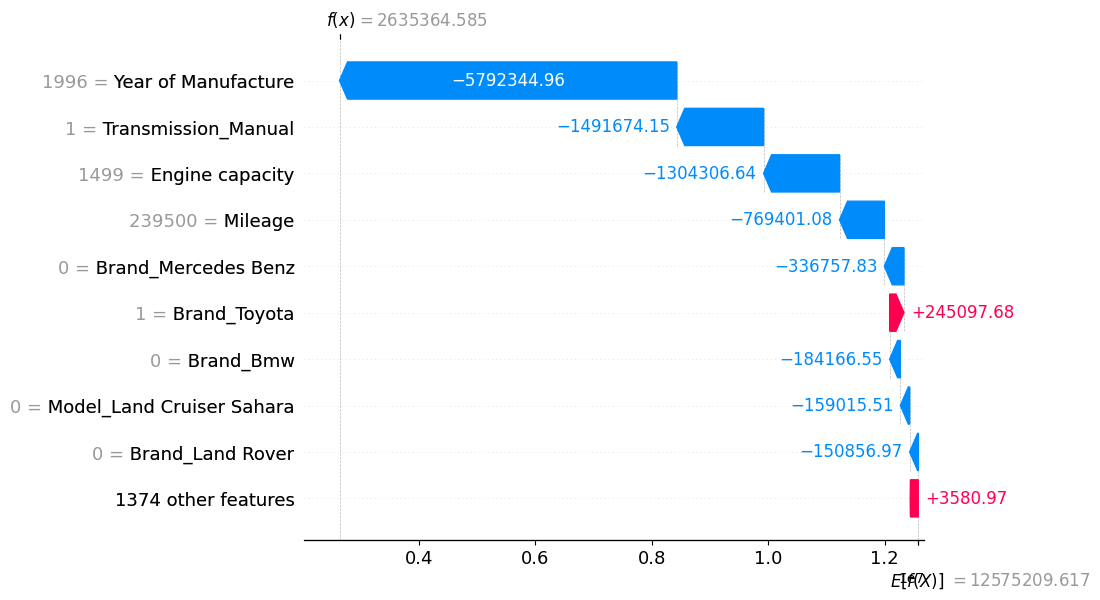

In [13]:
car_index = 0
single_car = X_test.iloc[[car_index]]

print(f"--- Explaining Prediction for Car #{car_index} ---")
print(f"Actual Price: Rs. {y_test.iloc[car_index]:,.2f}")
print(f"Predicted Price: Rs. {best_xgb.predict(single_car)[0]:,.2f}\n")

X_train_shap = X_train.astype(float)
single_car_shap = single_car.astype(float)

explainer_waterfall = shap.Explainer(best_xgb, X_train_shap)
shap_values_waterfall = explainer_waterfall(single_car_shap)

shap.plots.waterfall(shap_values_waterfall[0], max_display=10)

In [14]:
import pickle

model_data = {
    'model': best_xgb,
    'features': list(X_train.columns)
}

with open('used_car_xgboost_model.pkl', 'wb') as file:
    pickle.dump(model_data, file)

print("Model saved as 'used_car_xgboost_model.pkl'.")

Model saved as 'used_car_xgboost_model.pkl'.
